# Netflix Content Analytics

**Business problem:** Analyze genre trends, ratings, and engagement across Netflix's content library.

**Skills:** SQL + Python · Trend analysis · Visualization · Data storytelling

---
This notebook is *scaffolded*: the setup, cleaning, and the first SQL queries are
done for you. Sections marked **YOUR TURN** are where you build the analysis
yourself. The whole point is that you write those parts — that's where the learning is.


## Phase 0 — Setup

In [1]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
print("Libraries loaded.")

Libraries loaded.


## Phase 1 — Load the data

We start from `netflix_titles.csv`. First thing any analyst does: get your bearings
before you touch anything.

In [2]:
df = pd.read_csv("../data/netflix_titles.csv")
print("Shape:", df.shape)
df.head()

Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [4]:
# Where are the gaps? (Missing data is a finding, not just a nuisance.)
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## Phase 2 — Clean the data

Five problems live in this dataset. We fix them one at a time so you can see each move.

1. Duplicate rows
2. `date_added` is stored in **three different formats** + some missing
3. `duration` mixes minutes (movies) and seasons (TV) in one column
4. `listed_in` packs multiple genres into one comma-separated string
5. Nulls in `director`, `cast`, `country`, `rating`

**2.1 — Drop exact duplicates**

In [5]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows. Now {len(df)} rows.")

Removed 0 duplicate rows. Now 8807 rows.


**2.2 — Parse the messy dates**

`pd.to_datetime` with `format='mixed'` handles the three formats in one shot.
Anything unparseable becomes `NaT` (which we keep — missing-ness is informative).

In [6]:
df["date_added"] = pd.to_datetime(
    df["date_added"].str.strip(), format="mixed", errors="coerce"
)
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month
print("Date range:", df["year_added"].min(), "->", df["year_added"].max())
df[["date_added", "year_added", "month_added"]].head()

Date range: 2008.0 -> 2021.0


,date_added,year_added,month_added
0,2021-09-25,2021.0,9.0
1,2021-09-24,2021.0,9.0
2,2021-09-24,2021.0,9.0
3,2021-09-24,2021.0,9.0
4,2021-09-24,2021.0,9.0


**2.3 — Split duration into a number + a unit**

Movies are measured in minutes, TV in seasons. We separate the value from the unit
so each can be analyzed on its own terms.

In [7]:
df["duration_int"] = df["duration"].str.extract(r"(\d+)").astype(float)
df["duration_unit"] = np.where(df["type"] == "Movie", "min", "seasons")
df[["type", "duration", "duration_int", "duration_unit"]].head()

,type,duration,duration_int,duration_unit
0,Movie,90 min,90.0,min
1,TV Show,2 Seasons,2.0,seasons
2,TV Show,1 Season,1.0,seasons
3,TV Show,1 Season,1.0,seasons
4,TV Show,2 Seasons,2.0,seasons


**2.4 — Explode the genres** ⭐

This is the single most important move in the project. The `listed_in` column looks like
`"Dramas, International Movies"`. We split it into a list, then `explode()` turns each
genre into its own row — so one title with 3 genres becomes 3 rows. This unlocks all
genre-level analysis.

In [8]:
df["genre_list"] = df["listed_in"].str.split(", ")
df_genres = df.explode("genre_list").rename(columns={"genre_list": "genre"})
df_genres["genre"] = df_genres["genre"].str.strip()
print(f"Title-level rows: {len(df)}  ->  Genre-level rows: {len(df_genres)}")
df_genres[["title", "type", "genre", "year_added"]].head(6)

Title-level rows: 8807  ->  Genre-level rows: 19323


,title,type,genre,year_added
0,Dick Johnson Is Dead,Movie,Documentaries,2021.0
1,Blood & Water,TV Show,International TV Shows,2021.0
1,Blood & Water,TV Show,TV Dramas,2021.0
1,Blood & Water,TV Show,TV Mysteries,2021.0
2,Ganglands,TV Show,Crime TV Shows,2021.0
2,Ganglands,TV Show,International TV Shows,2021.0


**2.5 — Handle remaining nulls**

Different columns deserve different treatment. For categorical fields we use
`"Unknown"` so the rows survive for other analyses; we leave dates as `NaT`.

In [9]:
for col in ["director", "cast", "country", "rating"]:
    df[col] = df[col].fillna("Unknown")
    if col in df_genres.columns:
        df_genres[col] = df_genres[col].fillna("Unknown")
print("Remaining nulls in df:")
print(df.isnull().sum())

Remaining nulls in df:
show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added       10
release_year      0
rating            0
duration          3
listed_in         0
description       0
year_added       10
month_added      10
duration_int      3
duration_unit     0
genre_list        0
dtype: int64


## Phase 3 — Analyze with SQL (DuckDB)

DuckDB runs SQL directly on a pandas DataFrame — no database server, no imports.
Just reference the DataFrame by its variable name inside the query.

The first three queries are done for you as worked examples. Then it's **YOUR TURN**.

**Q1 — Movies vs. TV Shows (worked example)**

In [10]:
duckdb.sql("""
    SELECT type, COUNT(*) AS title_count
    FROM df
    GROUP BY type
    ORDER BY title_count DESC
""").df()

,type,title_count
0,Movie,6131
1,TV Show,2676


**Q2 — Top 10 genres overall (worked example)**

In [11]:
duckdb.sql("""
    SELECT genre, COUNT(*) AS title_count
    FROM df_genres
    GROUP BY genre
    ORDER BY title_count DESC
    LIMIT 10
""").df()

,genre,title_count
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1351
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,763
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


**Q3 — Genre trend over time (worked example)**

This is your *trend analysis* core: titles added per genre per year. We filter to a few
genres to keep it readable; you'll expand this.

In [12]:
duckdb.sql("""
    SELECT year_added, genre, COUNT(*) AS titles
    FROM df_genres
    WHERE genre IN ('Dramas', 'Comedies', 'Documentaries')
      AND year_added IS NOT NULL
    GROUP BY year_added, genre
    ORDER BY year_added, genre
""").df().head(12)

,year_added,genre,titles
0,2008.0,Dramas,1
1,2009.0,Dramas,1
2,2011.0,Dramas,13
3,2012.0,Comedies,2
4,2012.0,Documentaries,1
5,2013.0,Comedies,1
6,2013.0,Documentaries,1
7,2014.0,Comedies,2
8,2014.0,Documentaries,8
9,2015.0,Comedies,12


In [14]:
# Q4 — Ratings distribution: count titles per rating (TV-MA, PG-13, ...), sorted.
# Hint: GROUP BY rating on df.
duckdb.sql("""
    SELECT rating, COUNT(*) AS title_count
    FROM df
    WHERE rating != 'Unknown'
    GROUP BY rating
    ORDER BY title_count DESC
""").df()


,rating,title_count
0,TV-MA,399
1,TV-PG,363
2,TV-14,361
3,R,234
4,NR,230
5,NC-17,215
6,G,214
7,PG,208
8,PG-13,208
9,TV-Y7,157


In [13]:
# Q5 — Top 10 producing countries.
duckdb.sql("""
    SELECT country, COUNT(*) AS title_count
    FROM df
    WHERE country != 'Unknown'
    GROUP BY country
    ORDER BY title_count DESC
    LIMIT 10
""").df()

,country,title_count
0,United States,2818
1,India,972
2,United Kingdom,419
3,Japan,245
4,South Korea,199
5,Canada,181
6,Spain,145
7,France,124
8,Mexico,110
9,Egypt,106


In [16]:
# Q6 — Is Netflix skewing more mature over time?
duckdb.sql("""
    SELECT year_added,
           rating,
           COUNT(*) AS titles
    FROM df
    WHERE year_added IS NOT NULL
      AND rating != 'Unknown'
    GROUP BY year_added, rating
    ORDER BY year_added, titles DESC
""").df()

,year_added,rating,titles
0,2008.0,TV-MA,288
1,2008.0,TV-PG,270
2,2008.0,TV-14,261
3,2008.0,NR,180
4,2008.0,R,172
...,...,...,...
150,2021.0,NR,10
151,2021.0,TV-Y,9
152,2021.0,PG-13,8
153,2021.0,TV-Y7,7


In [14]:
# Q7 — Catalog freshness: how old is content when added?
duckdb.sql("""
    SELECT year_added,
           ROUND(AVG(year_added - release_year), 1) AS avg_age_at_add
    FROM df
    WHERE year_added IS NOT NULL
    GROUP BY year_added
    ORDER BY year_added
""").df()

,year_added,avg_age_at_add
0,2008.0,1.5
1,2009.0,1.0
2,2010.0,23.0
3,2011.0,19.9
4,2012.0,1.0
5,2013.0,0.5
6,2014.0,3.0
7,2015.0,1.3
8,2016.0,2.9
9,2017.0,3.9


In [18]:
# Q8 — Top genre per year (window function) ⭐
duckdb.sql("""
    WITH yearly AS (
        SELECT year_added, genre, COUNT(*) AS n
        FROM df_genres
        WHERE year_added IS NOT NULL
        GROUP BY year_added, genre
    )
    SELECT year_added, genre, n
    FROM (
        SELECT *,
               ROW_NUMBER() OVER (PARTITION BY year_added ORDER BY n DESC) AS rk
        FROM yearly
    )
    WHERE rk = 1
    ORDER BY year_added
""").df()

,year_added,genre,n
0,2008.0,TV Dramas,225
1,2009.0,Music & Musicals,6
2,2010.0,Crime TV Shows,7
3,2011.0,TV Comedies,6
4,2012.0,Comedies,8
5,2013.0,Sci-Fi & Fantasy,7
6,2014.0,Stand-Up Comedy,6
7,2015.0,Reality TV,7
8,2016.0,Romantic Movies,5
9,2017.0,British TV Shows,10


In [15]:
# Q9 — Year-over-year growth in titles added (window function)
duckdb.sql("""
    WITH yearly_totals AS (
        SELECT year_added, COUNT(*) AS total
        FROM df
        WHERE year_added IS NOT NULL
        GROUP BY year_added
    )
    SELECT year_added,
           total,
           LAG(total) OVER (ORDER BY year_added) AS prev_year,
           ROUND(
               100.0 * (total - LAG(total) OVER (ORDER BY year_added))
               / LAG(total) OVER (ORDER BY year_added), 1
           ) AS yoy_growth_pct
    FROM yearly_totals
    ORDER BY year_added
""").df()

,year_added,total,prev_year,yoy_growth_pct
0,2008.0,2,<NA>,NaN
1,2009.0,2,2,0.0
2,2010.0,1,2,-50.0
3,2011.0,13,1,1200.0
4,2012.0,3,13,-76.9
5,2013.0,11,3,266.7
6,2014.0,24,11,118.2
7,2015.0,82,24,241.7
8,2016.0,429,82,423.2
9,2017.0,1188,429,176.9


## Phase 4 — Visualize

**V1 — Top genres (worked example)**

FileNotFoundError: [Errno 2] No such file or directory: 'visuals/top_genres.png'

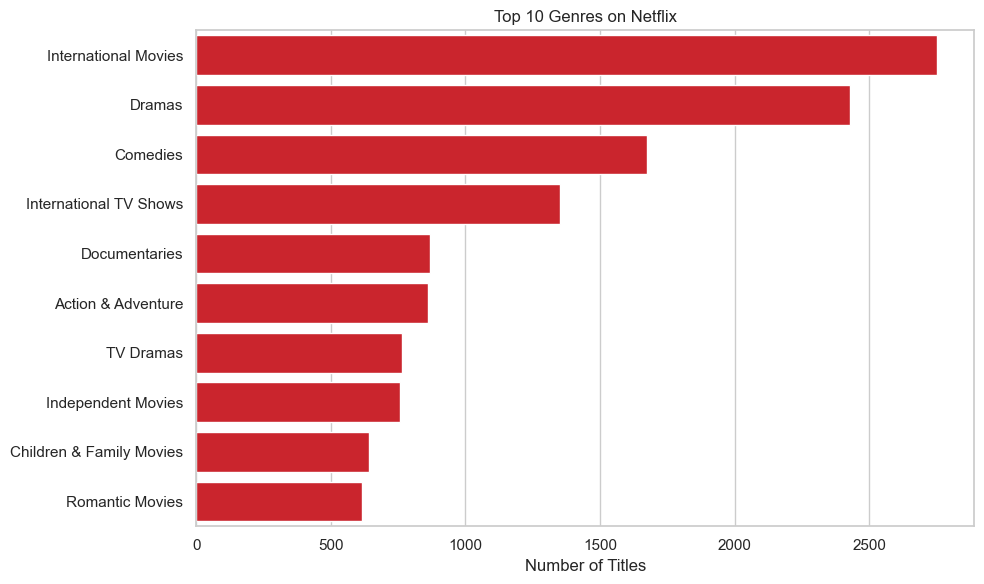

In [ ]:
top_genres = duckdb.sql("""
    SELECT genre, COUNT(*) AS title_count
    FROM df_genres GROUP BY genre ORDER BY title_count DESC LIMIT 10
""").df()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_genres, x="title_count", y="genre", color="#E50914")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles"); plt.ylabel("")
plt.tight_layout()
plt.savefig("../visuals/top_genres.png", dpi=150)
plt.show()

**V2 — Genre trends over time (worked example)**

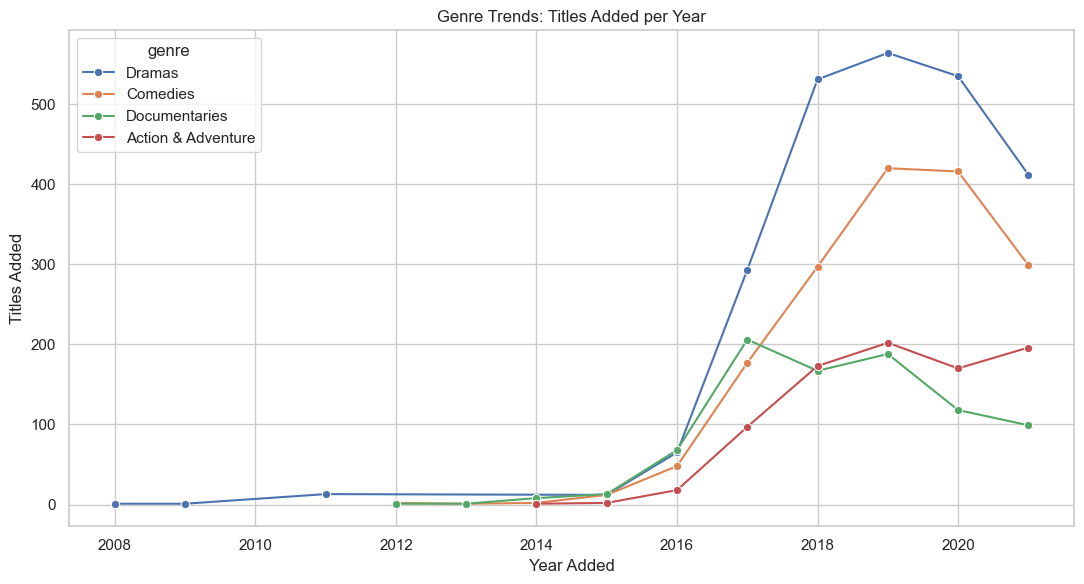

In [19]:
trend = duckdb.sql("""
    SELECT year_added, genre, COUNT(*) AS titles
    FROM df_genres
    WHERE genre IN ('Dramas','Comedies','Documentaries','Action & Adventure')
      AND year_added IS NOT NULL
    GROUP BY year_added, genre ORDER BY year_added
""").df()

plt.figure(figsize=(11, 6))
sns.lineplot(data=trend, x="year_added", y="titles", hue="genre", marker="o")
plt.title("Genre Trends: Titles Added per Year")
plt.xlabel("Year Added"); plt.ylabel("Titles Added")
plt.tight_layout()
plt.show()

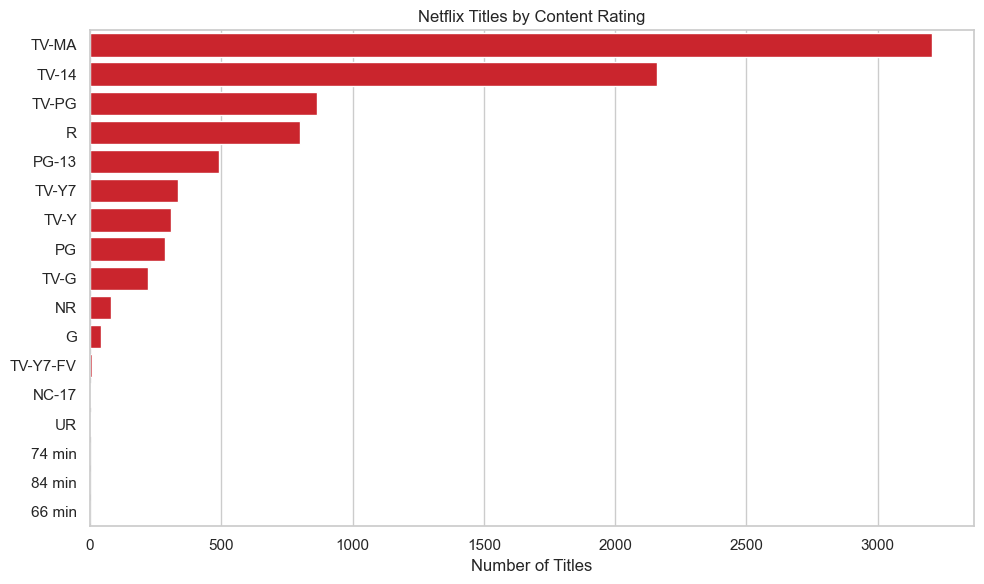

In [20]:
# V3 — Ratings distribution (bar chart, builds on Q4)
ratings = duckdb.sql("""
    SELECT rating, COUNT(*) AS title_count
    FROM df
    WHERE rating != 'Unknown'
    GROUP BY rating
    ORDER BY title_count DESC
""").df()

plt.figure(figsize=(10, 6))
sns.barplot(data=ratings, x="title_count", y="rating", color="#E50914")
plt.title("Netflix Titles by Content Rating")
plt.xlabel("Number of Titles"); plt.ylabel("")
plt.tight_layout()
plt.savefig("../visuals/ratings_distribution.png", dpi=150)
plt.show()

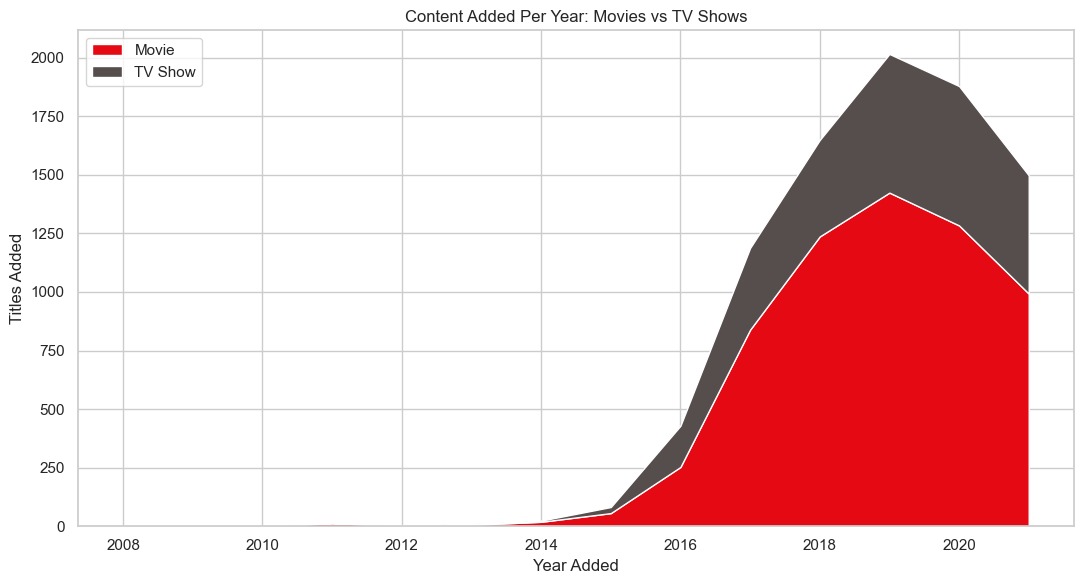

In [21]:
# V4 — Movies vs TV Shows added per year (stacked area)
type_trend = duckdb.sql("""
    SELECT year_added, type, COUNT(*) AS titles
    FROM df
    WHERE year_added IS NOT NULL
    GROUP BY year_added, type
    ORDER BY year_added
""").df()

# Pivot so each type becomes its own column for stacking
pivot = type_trend.pivot(index="year_added", columns="type", values="titles").fillna(0)

plt.figure(figsize=(11, 6))
plt.stackplot(pivot.index, pivot["Movie"], pivot["TV Show"],
              labels=["Movie", "TV Show"], colors=["#E50914", "#564d4d"])
plt.title("Content Added Per Year: Movies vs TV Shows")
plt.xlabel("Year Added"); plt.ylabel("Titles Added")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig("../visuals/type_trend.png", dpi=150)
plt.show()

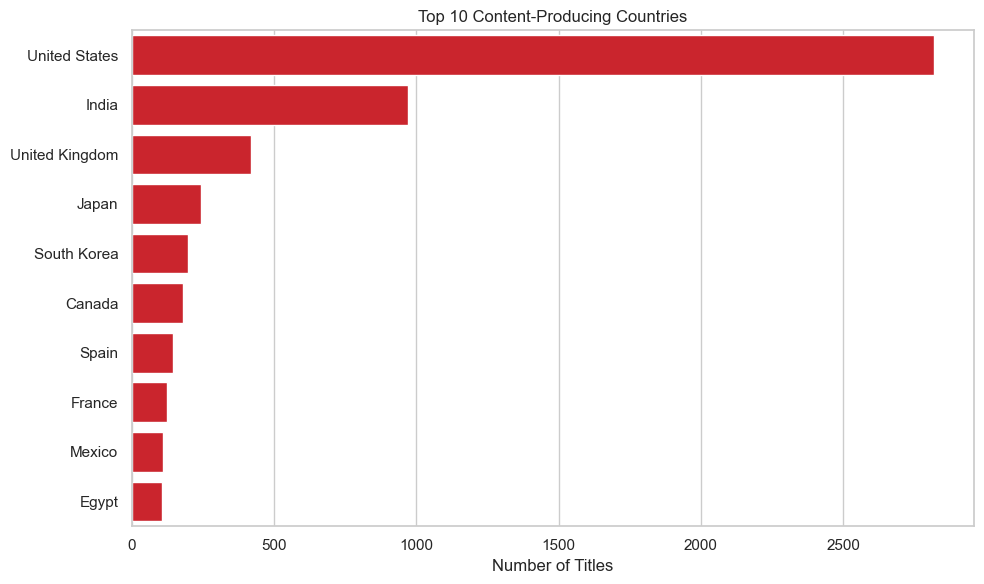

In [22]:
# V5 — Top 10 producing countries (horizontal bar, builds on Q5)
countries = duckdb.sql("""
    SELECT country, COUNT(*) AS title_count
    FROM df
    WHERE country != 'Unknown'
    GROUP BY country
    ORDER BY title_count DESC
    LIMIT 10
""").df()

plt.figure(figsize=(10, 6))
sns.barplot(data=countries, x="title_count", y="country", color="#E50914")
plt.title("Top 10 Content-Producing Countries")
plt.xlabel("Number of Titles"); plt.ylabel("")
plt.tight_layout()
plt.savefig("../visuals/top_countries.png", dpi=150)
plt.show()

## Phase 5 — Tell the story


Finding 1 — Netflix's content engine switched on in the mid-2010s and peaked in 2019.
Title additions were negligible before ~2014, then accelerated sharply, peaking at 2,016 titles in 2019 with 2020 close behind (1,879). This reflects Netflix's transformation from a licensing-driven catalog into an aggressive content-acquisition platform during the streaming-wars era. (Chart: V4)

Finding 2 — The catalog is movie-heavy by count (70/30), but that understates TV.
Movies make up 69.6% of titles (6,131) versus 30.4% for TV shows (2,676) — roughly a 70/30 split. However, title counts understate TV's strategic weight: one series represents far more watch-time and subscriber retention than one film, so a catalog that looks movie-dominated by count is likely far more balanced by actual engagement. (Chart: V4)

Finding 3 — "International Movies" is the single largest genre, signaling a global-first strategy.
The top genres are International Movies (2,752), Dramas (2,427), and Comedies (1,674). The fact that the #1 category is international — ahead of any domestic genre — points to a deliberate strategy of acquiring globally to serve international subscriber growth, not just a US-centric library. (Chart: V1 / Q2)

Finding 4 — The library skews heavily toward mature content.
TV-MA is by far the most common rating (3,207 titles), followed by TV-14 (2,160), with family ratings like TV-PG (863) trailing well behind. Netflix's catalog is built primarily for adult audiences, consistent with a service competing on prestige and edgy originals rather than family-friendly breadth. (Chart: V3 / Q6)




In [23]:
# Phase 5 — pull the exact numbers for the findings

print("=== F1: Peak year of additions ===")
print(duckdb.sql("""
    SELECT year_added, COUNT(*) AS titles
    FROM df WHERE year_added IS NOT NULL
    GROUP BY year_added ORDER BY titles DESC LIMIT 3
""").df())

print("\n=== F2: Movie vs TV share ===")
print(duckdb.sql("""
    SELECT type,
           COUNT(*) AS titles,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM df GROUP BY type ORDER BY titles DESC
""").df())

print("\n=== F3: Top 5 genres ===")
print(duckdb.sql("""
    SELECT genre, COUNT(*) AS titles
    FROM df_genres GROUP BY genre ORDER BY titles DESC LIMIT 5
""").df())

print("\n=== F4 option A: Top 5 ratings ===")
print(duckdb.sql("""
    SELECT rating, COUNT(*) AS titles
    FROM df WHERE rating != 'Unknown'
    GROUP BY rating ORDER BY titles DESC LIMIT 5
""").df())

print("\n=== F4 option B: Top 5 countries ===")
print(duckdb.sql("""
    SELECT country, COUNT(*) AS titles
    FROM df WHERE country != 'Unknown'
    GROUP BY country ORDER BY titles DESC LIMIT 5
""").df())

=== F1: Peak year of additions ===
   year_added  titles
0      2019.0    2016
1      2020.0    1879
2      2018.0    1649

=== F2: Movie vs TV share ===
      type  titles   pct
0    Movie    6131  69.6
1  TV Show    2676  30.4

=== F3: Top 5 genres ===
                    genre  titles
0    International Movies    2752
1                  Dramas    2427
2                Comedies    1674
3  International TV Shows    1351
4           Documentaries     869

=== F4 option A: Top 5 ratings ===
  rating  titles
0  TV-MA    3207
1  TV-14    2160
2  TV-PG     863
3      R     799
4  PG-13     490

=== F4 option B: Top 5 countries ===
          country  titles
0   United States    2818
1           India     972
2  United Kingdom     419
3           Japan     245
4     South Korea     199
